<a href="https://colab.research.google.com/github/DhangeSakshiSanjay/Celebal_Weekly_Assignments/blob/main/week5_Sakshi_Dhange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**
**Name : Sakshi Sanjay Dhange (Sanjivani COE)**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = """
Artificial Intelligence is transforming many industries by making machines capable of learning from data.
Machine learning is a branch of artificial intelligence that helps computers improve through experience.
Deep learning is a powerful technique that uses multiple layers of neural networks.
Natural language processing enables computers to understand and generate human language.
Text generation models learn the relationship between words in a sentence.
RNN is one of the first neural network models designed for sequential data.
LSTM improves the performance of RNN by remembering important information for a longer time.
GRU is a simpler version of LSTM that provides good accuracy with fewer parameters.
These models are widely used in chatbots, language translation, speech recognition, and text prediction.
As the amount of training data increases, text generation models usually produce more meaningful and natural sentences.
"""
print(corpus)


Artificial Intelligence is transforming many industries by making machines capable of learning from data.
Machine learning is a branch of artificial intelligence that helps computers improve through experience.
Deep learning is a powerful technique that uses multiple layers of neural networks.
Natural language processing enables computers to understand and generate human language.
Text generation models learn the relationship between words in a sentence.
RNN is one of the first neural network models designed for sequential data.
LSTM improves the performance of RNN by remembering important information for a longer time.
GRU is a simpler version of LSTM that provides good accuracy with fewer parameters.
These models are widely used in chatbots, language translation, speech recognition, and text prediction.
As the amount of training data increases, text generation models usually produce more meaningful and natural sentences.



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 93
X shape: (125, 16)
y shape: (125,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

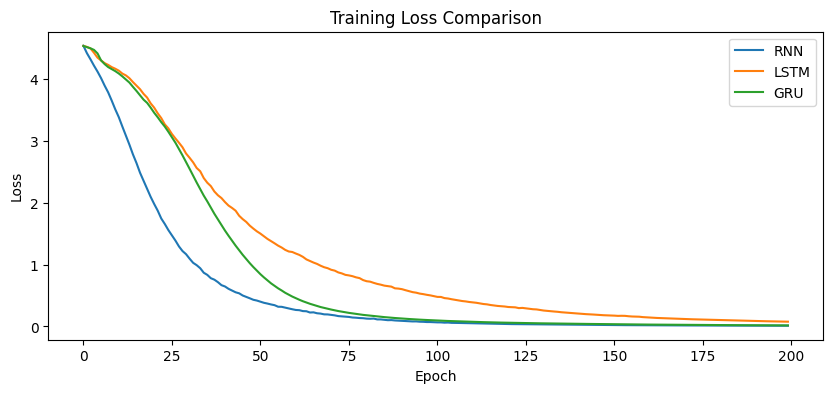

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [10]:
print("RNN :", generate_text(rnn_model, "Artificial Intelligence", 10))
print("LSTM:", generate_text(lstm_model, "Artificial Intelligence", 10))
print("GRU :", generate_text(gru_model, "Artificial Intelligence", 10))

RNN : Artificial Intelligence is transforming many industries by making machines capable of learning
LSTM: Artificial Intelligence is transforming many industries by making machines capable of learning
GRU : Artificial Intelligence is transforming many industries by making machines capable of learning


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

## My Conclusion

In this assignment, I implemented and compared three Recurrent Neural Network (RNN) models: Vanilla RNN, LSTM, and GRU for text generation using a small custom text dataset.

All three models were able to learn the basic sentence patterns and generate text from the given starting words. Since the dataset was small, the generated sentences contained some repeated words and were not always meaningful.

From the results, I observed that the Vanilla RNN could learn simple and short patterns, but it had difficulty remembering information over longer sequences. The LSTM generated better and more meaningful text because it can remember important information for a longer time. The GRU also produced good results similar to the LSTM while using a simpler structure and requiring less training time.

Overall, this assignment helped me understand how different RNN models work for text generation. It also showed that LSTM and GRU generally perform better than a basic Vanilla RNN for learning sequential data and generating more consistent text.


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**